### **Que:** Create a web scrapping application using selenium which can insert anything in the searchbox/form, move forward and backward quit after doing all the basic operations

In [ ]:
# Install Chrome
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt -qq install -y ./google-chrome-stable_current_amd64.deb

# Install required libraries
!pip install -q selenium webdriver-manager

google-chrome-stable is already the newest version (148.0.7778.167-1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [ ]:

from selenium import webdriver # The main module that launches and controls the web browser
from selenium.webdriver.chrome.service import Service # Handles the background service for ChromeDriver
from webdriver_manager.chrome import ChromeDriverManager # Automatically downloads and updates the correct Chrome driver version

# For segregation and typing
from selenium.webdriver.common.by import By # Helps locate web elements (like buttons or text boxes) using ID, Name, CSS, etc.
from selenium.webdriver.common.keys import Keys # Allows you to simulate keyboard actions like pressing ENTER, ECS, or ARROW keys

# For operations and time applications
from selenium.webdriver.chrome.options import Options # Used to customize browser settings(like running in backgroud/headless mode)
import pandas as pd # Used to orginize data into tables and save it as CSV/Excel files
import time # Used to add pauses or delays in the script to wait for pages to load

In [ ]:
# Setup browser settings
options = Options()
options.add_argument("--headless=new") # Run browser in background (invisible)
options.add_argument("--no-sandbox") # Don't open browser in real time
options.add_argument("--disable-dev-shm-usage") # Fix memory/RAM limits (issues se bachne ke liye)

In [ ]:
# Setup driver
service = Service(ChromeDriverManager().install()) # Auto downloads ans sets up the correct Chrome driver
driver = webdriver.Chrome(service=service, options=options) # Starts the Chrome browser with our settings

In [ ]:
# Open bing
driver.get("https://www.bing.com/?cc=in") # Opens the specified website URL
time.sleep(3) # Waits for 3 seconds to let page load

<html dir="ltr" lang="en" xml:lang="en" xmlns="http://www.w3.org/1999/xhtml" xmlns:web="http://schemas.live.com/Web/"><head><script type="text/javascript" nonce="">//<![CDATA[
si_ST=new Date
//]]></script><!--pc--><title>Machine Learning - Search</title><meta content="text/html; charset=utf-8" http-equiv="content-type"><meta name="referrer" content="origin-when-cross-origin"><meta property="og:description" content="Check out what I just created on Bing Image Creator"><meta property="og:site_name" content="Bing"><meta property="og:title" content="Machine Learning - Bing"><meta property="og:url" content="https://www.bing.com/search?q=Machine+Learning&amp;form=QBLH"><meta property="fb:app_id" content="3732605936979161"><meta property="og:image" content="http://www.bing.com/sa/simg/facebook_sharing_5.png"><meta property="og:type" content="website"><meta property="og:image:width" content="600"><meta property="og:image:height" content="315"><link rel="alternate" href="/search?format=rss&amp;
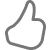

In [ ]:
# Search
search_box = driver.find_element(By.NAME,"q") # Find the search box on the webpage using its name "q"
search_box.send_keys("Machine Learning") # Types the word "Machine Learning" into that search box
search_box.send_keys(Keys.RETURN) # Presses the ENTER key to submit the search

time.sleep(5) # Wait for 5 second to let page load
print(driver.page_source) # Print page source (HTML Code) of "Machien Learning"

In [ ]:
# Print page title and href link
results = driver.find_elements(By.CSS_SELECTOR,"li.b_algo") # Find search box using its CSS SELECTOR (ID + Class)

data = []

for r in results[:5]:
  try:
    title = r.find_element(By.TAG_NAME,"h2").text # Extracts the text of the title
    link = r.find_element(By.TAG_NAME,"a").get_attribute("href") # Extracts the actual URL (link)
    data.append([title,link]) # Saves the title pair into our data list
  except:
    continue # If a result is broken, ignore the error and moves to the next one

In [ ]:
# Print results
print("Top 5 Results:\n")
for i, d in enumerate(data,1):
  print(f"{i}. {d[0]}")
  print(d[1])
  print()

Top 5 Results:

1. Machine Learning Tutorial - GeeksforGeeks
https://www.bing.com/ck/a?!&&p=8be4d4562c26deb33dd522cd2ad1f2004f308489eb438c3f7d7fb0bb00966526JmltdHM9MTc3ODU0NDAwMA&ptn=3&ver=2&hsh=4&fclid=221bb2c0-ee6b-6380-1ff0-a597efe66290&u=a1aHR0cHM6Ly93d3cuZ2Vla3Nmb3JnZWVrcy5vcmcvbWFjaGluZS1sZWFybmluZy9tYWNoaW5lLWxlYXJuaW5nLw&ntb=1

2. Machine Learning (ML) Tutorial - Online Tutorials Library
https://www.bing.com/ck/a?!&&p=3f96ed72e2c340e9dc14d207251a114e381a40b1bde6007edbc7359b4aa37154JmltdHM9MTc3ODU0NDAwMA&ptn=3&ver=2&hsh=4&fclid=221bb2c0-ee6b-6380-1ff0-a597efe66290&u=a1aHR0cHM6Ly93d3cudHV0b3JpYWxzcG9pbnQuY29tL21hY2hpbmVfbGVhcm5pbmcvaW5kZXguaHRt&ntb=1



In [ ]:
# Save to CSV format
df = pd.DataFrame(data, columns=["Title","Link"]) # Create a dataframe using pandas and add columns
df.to_csv("Bing_ML_result.csv", index=False) # Save into csv format and index false

print("Saved as Bing_ML_results.csv")

Saved as Bing_ML_results.csv


In [ ]:
# Move Backward
print("Moving BACKWORD to the Wikipedia home page..")
driver.back()
time.sleep(2)

Moving BACKWORD to the Wikipedia home page..


In [ ]:
# Move Forward
print("Moving FORWARD back to the search results..")
driver.forward()
time.sleep(2)

Moving FORWARD back to the search results..


In [ ]:
# Basuc Operations - Refresh the page
print("Refreshing the current page...")
driver.refresh()
time.sleep(2)

Refreshing the current page...


In [ ]:
# Quit the browser
print("Closing the browser")
driver.quit()
print("Automation Complete!")

Closing the browser
Automation Complete!
